In [ ]:
# ============================================
# TASK 3: CAR PRICE PREDICTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving CAR DETAILS FROM CAR DEKHO.csv to CAR DETAILS FROM CAR DEKHO (2).csv


In [ ]:
import io

filename = list(uploaded.keys())[0]

df = pd.read_csv(
    io.BytesIO(uploaded[filename])
)

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [ ]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape:
(4340, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 763


In [ ]:
df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())

Duplicates after removal: 0


In [ ]:
df.describe()

,year,selling_price,km_driven
count,3577.000000,3.577000e+03,3577.000000
mean,2012.962538,4.739125e+05,69250.545709
std,4.251759,5.093018e+05,47579.940016
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,36000.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [ ]:
# Calculate car age

current_year = 2026

df["car_age"] = current_year - df["year"]

df[["year", "car_age"]].head()

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [ ]:
# Extract brand from car name

df["brand"] = df["name"].str.split().str[0]

df[["name", "brand"]].head(10)

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda
5,Maruti Alto LX BSIII,Maruti
6,Hyundai Xcent 1.2 Kappa S,Hyundai
7,Tata Indigo Grand Petrol,Tata
8,Hyundai Creta 1.6 VTVT S,Hyundai
9,Maruti Celerio Green VXI,Maruti


Fuel Types:
fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64


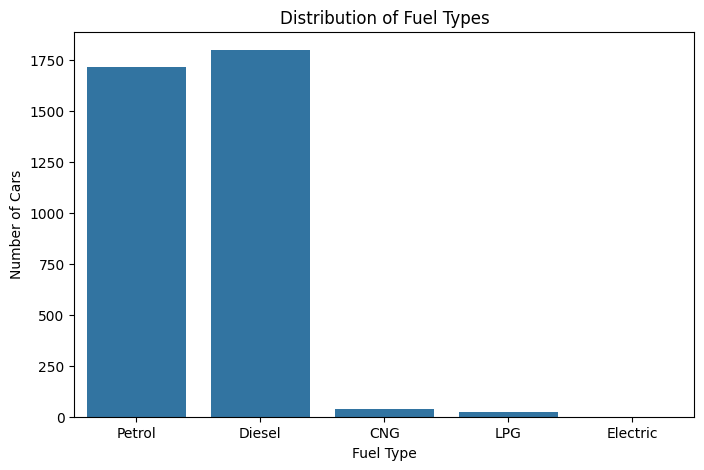

In [ ]:
print("Fuel Types:")
print(df["fuel"].value_counts())

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="fuel"
)

plt.title("Distribution of Fuel Types")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.show()

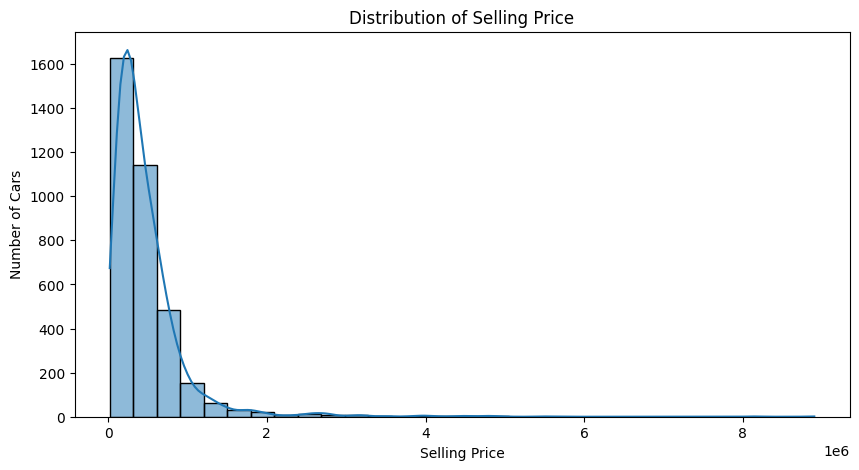

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="selling_price",
    bins=30,
    kde=True
)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

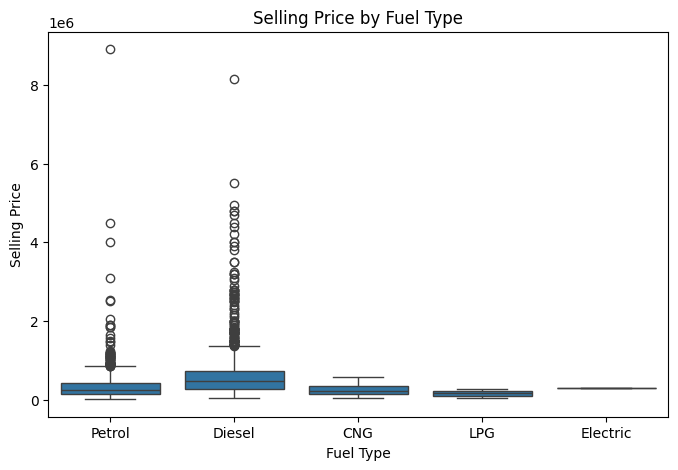

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

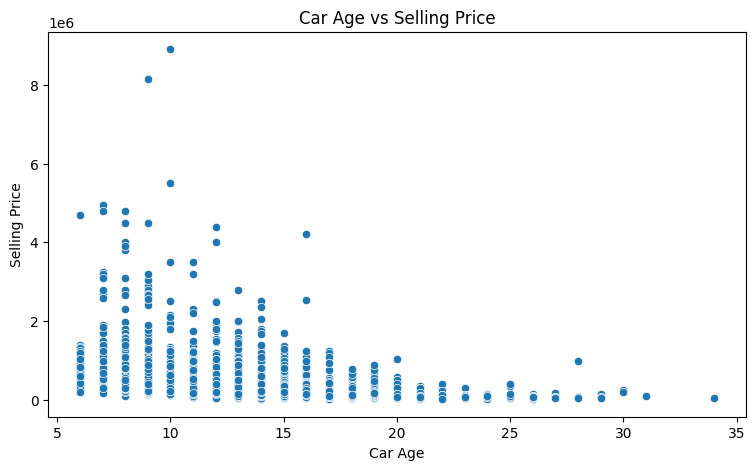

In [ ]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="car_age",
    y="selling_price"
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

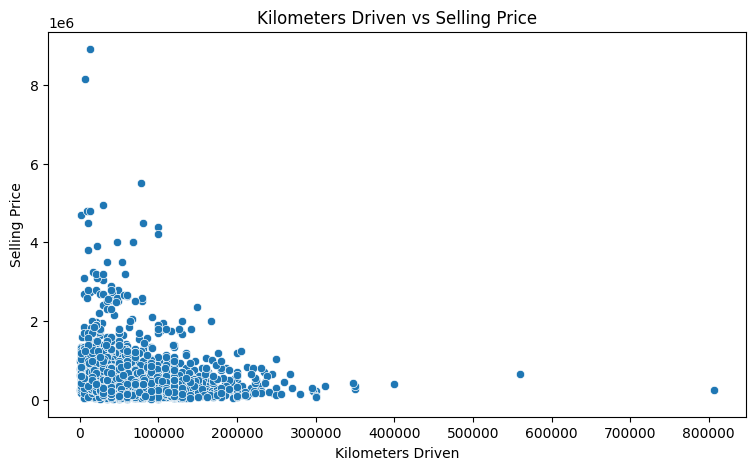

In [ ]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="km_driven",
    y="selling_price"
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.show()

Numerical columns used for correlation:
['year', 'selling_price', 'km_driven', 'car_age']


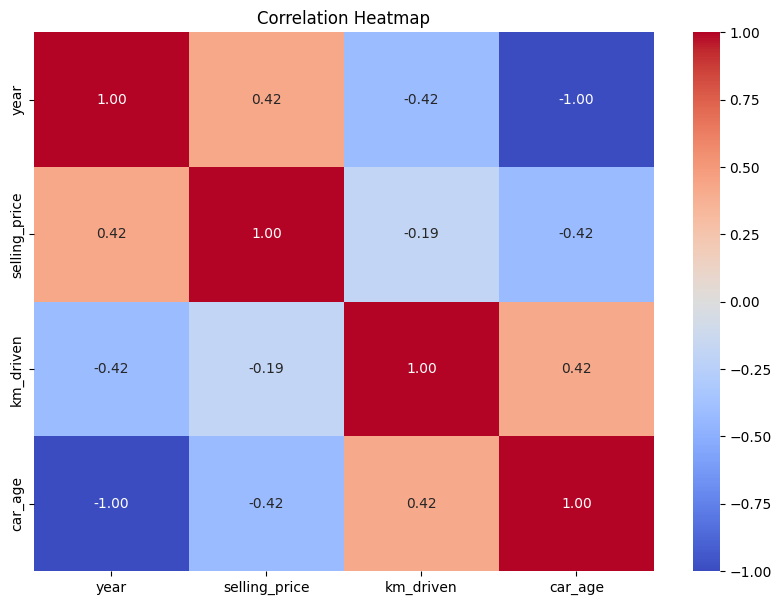

In [ ]:

# Select only numerical columns
numeric_df = df.select_dtypes(include=np.number)

print("Numerical columns used for correlation:")
print(numeric_df.columns.tolist())

# Calculate correlation
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Input features
X = df[
    [
        "km_driven",
        "fuel",
        "seller_type",
        "transmission",
        "owner",
        "car_age",
        "brand"
    ]
]

# Target variable
y = df["selling_price"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,141000,Diesel,Individual,Manual,Second Owner,12,Honda



Target:


,selling_price
0,60000
1,135000
2,600000
3,250000
4,450000


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2861, 7)
Testing data: (716, 7)


In [ ]:


categorical_features = [
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "brand"
]

numerical_features = [
    "km_driven",
    "car_age"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['fuel', 'seller_type', 'transmission', 'owner', 'brand']

Numerical features:
['km_driven', 'car_age']


In [ ]:


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Encoding completed successfully!")

Encoding completed successfully!


In [ ]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [ ]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("LINEAR REGRESSION")
print("=================")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

LINEAR REGRESSION
MAE : 179641.77
RMSE: 384722.7
R²  : 0.5405


In [56]:
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(
    X_test
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [57]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("RANDOM FOREST")
print("=============")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

RANDOM FOREST
MAE : 158380.94
RMSE: 364008.8
R²  : 0.5887


In [59]:


results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,179641.768082,384722.698405,0.540527
1,Random Forest,158380.941213,364008.803465,0.588672


In [ ]:


results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,179641.768082,384722.698405,0.540527
1,Random Forest,158380.941213,364008.803465,0.588672


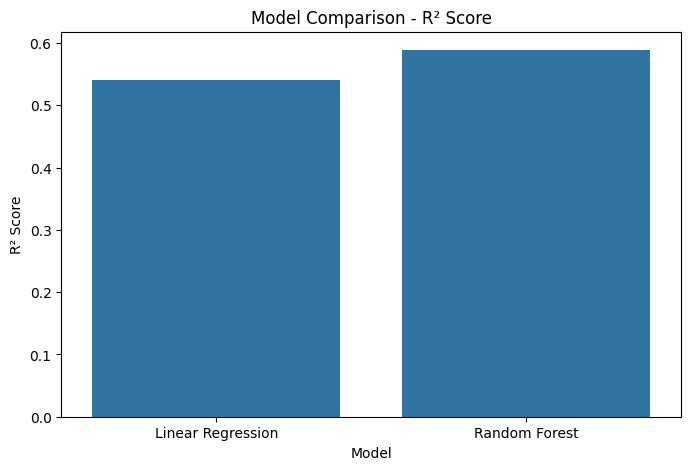

In [60]:


plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

In [61]:


if rf_r2 > linear_r2:
    best_model_name = "Random Forest"
    best_predictions = rf_predictions
    best_r2 = rf_r2
else:
    best_model_name = "Linear Regression"
    best_predictions = linear_predictions
    best_r2 = linear_r2

print("Best Model:", best_model_name)
print("Best R² Score:", round(best_r2, 4))

Best Model: Random Forest
Best R² Score: 0.5887


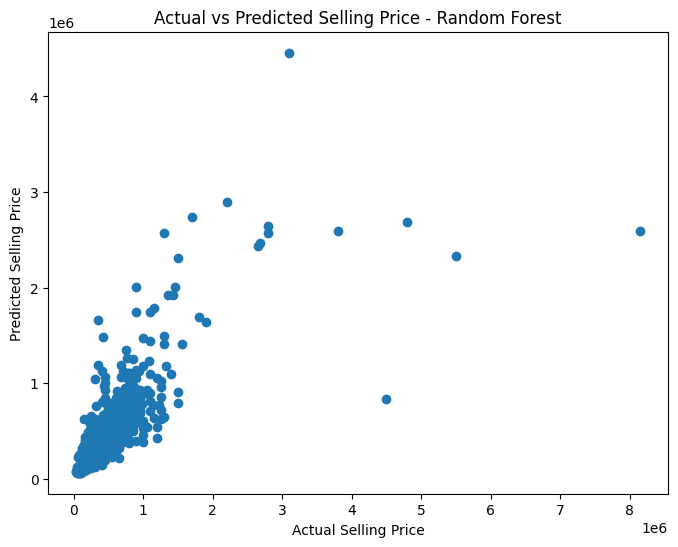

In [62]:


plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.title(
    f"Actual vs Predicted Selling Price - {best_model_name}"
)

plt.show()

In [63]:


rf_model = random_forest.named_steps["model"]

rf_preprocessor = random_forest.named_steps["preprocessor"]

# Get encoded categorical feature names
encoded_features = (
    rf_preprocessor
    .named_transformers_["categorical"]
    .get_feature_names_out(categorical_features)
)

# Combine feature names
feature_names = list(encoded_features) + numerical_features

# Get importance
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
42,car_age,0.221186
41,km_driven,0.132931
7,transmission_Automatic,0.129063
8,transmission_Manual,0.118515
1,fuel_Diesel,0.070895
15,brand_Audi,0.048344
3,fuel_Petrol,0.044750
27,brand_Land,0.040015
38,brand_Toyota,0.036909
16,brand_BMW,0.014530


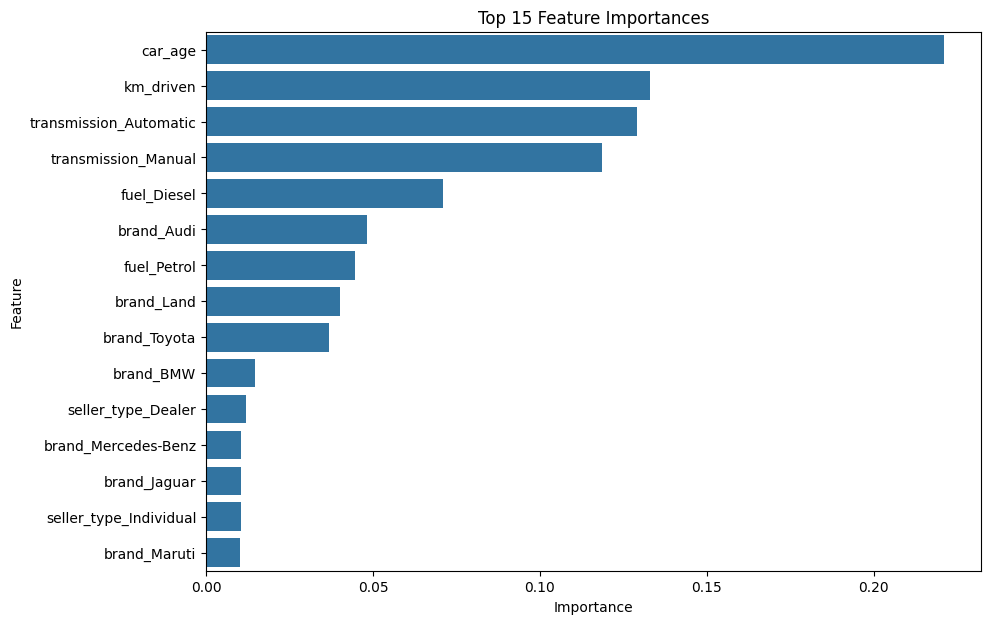

In [64]:


top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# Conclusion

In this project, a machine learning model was developed to predict
the selling price of used cars using the CarDekho vehicle dataset.

The dataset was checked for missing values and duplicate records.
Feature engineering was performed by calculating car age and
extracting the car brand from the vehicle name.

Exploratory Data Analysis was performed using different
visualizations, including fuel-type distribution, selling-price
distribution, car age versus selling price, and a correlation
heatmap.

Two regression models were implemented:

1. Linear Regression
2. Random Forest Regressor

The models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the higher R² score and lower prediction errors
was considered the better-performing model.

Feature importance analysis was also performed to understand
which features contributed most to predicting car prices.